## Make plots for cells with collisions
First use **collision_analysis.ipynb** to make a dictionary of collision properties for cells with significant change points. Then, use this notebook to make various plots for the collision cells.


#### TODO
- modify code to take multiple sessions
- check save paths

In [1]:
import numpy as np

from scipy import stats
from scipy.spatial import distance as dist
from scipy.signal import find_peaks
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

import format_chronic_stim
import stim_plots

import sys
sys.path.append("..//neural/")
import format_waveform_data
import waveform_analysis
import wormhole_analysis as analysis

import scipy.io
import os

### Load the data for each condition/session

In [2]:
''' set paths '''
# set parent directory
root_dir = "Z:/Isabel/data/hpc_implants/" # locker
# root_dir = "../data/antidromic_stim/" # local

# session params
bird_id = "LMN146"
session_id = "251114"
ephys_id = "LMN146_251114_113204"
stim_pols = ["neg"]
broken_channels = np.asarray([23, 48, 51])
show_plots = False
only_good = True

# data dirs
session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/{ephys_id}/" # locker
# session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/" # local
ks_dir = "kilosort4_blanked/"
ephys_dir = f"{session_dir}raw_ephys_output/"

# set save folder
save_folder = f"../figures/antidromic_hpc_to_lhy/{bird_id}/{bird_id}_{session_id}/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)

save folder exists


In [3]:
''' basic params '''
sampling_rate = 30000
t_pre = 0.02 # seconds collected before stim starts
t_post = 0.03 # seconds collected after stim time

''' universal fig params '''
# font sizes
title_size = 14
axis_label = 12
tick_label = 10

In [4]:
''' load and preprocess the data '''
all_stim_times = []
all_filt_data = []
for stim_pol in stim_pols:
    print(f"\nloading and processing data for polarity = {stim_pol}")
    raw_ephys = format_chronic_stim.load_stim(ephys_dir, stim_pol=stim_pol)
    sorted_ephys, ch_names = format_chronic_stim.sort_stim_by_channel(ephys_dir, raw_ephys)
    [n_channels, n_samples, n_stim] = sorted_ephys.shape

    # get the stim times
    stim_times = np.load(f'{ephys_dir}stim_t_{stim_pol}.npy')
    stim_times = np.squeeze(stim_times.astype(int))
    assert(stim_times.shape[0]==n_stim)
    
    # get the channel info and crop as-needed
    start_idx = 0
    end_idx = n_stim
    ephys_data, ch_names = format_chronic_stim.trim_stim_data(sorted_ephys, ch_names,
                                                              broken_ch=broken_channels,
                                                              start_idx=start_idx, end_idx=end_idx)
    # data params
    [n_channels, n_samples, n_stim] = ephys_data.shape
    stim_times = stim_times[start_idx:end_idx]
    assert(stim_times.shape[0]==n_stim)
    print(f"n channels = {n_channels}, samples = {n_samples}, stim events = {n_stim}")
    
    # filter the data
    filt_data = format_chronic_stim.filter_stim_for_spikes(ephys_data)
    
    # save for each polarity
    all_stim_times.append(stim_times)
    all_filt_data.append(filt_data)


loading and processing data for polarity = neg
loaded 2792 stim events in 86.23030640004436 seconds
Z:/Isabel/data/hpc_implants/LMN146/LMN146_251114/LMN146_251114_113204/raw_ephys_output/intan_info.mat
n channels = 61, samples = 1500, stim events = 2792


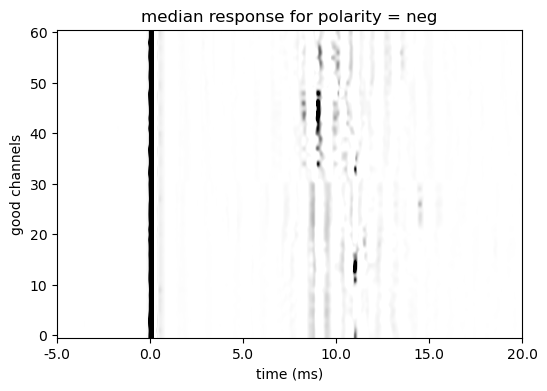

In [5]:
''' plot the median filtered hash for each polarity '''
for i, stim_pol in enumerate(stim_pols):
    f, ax = stim_plots.plot_avg_stim(all_filt_data[i], v_max=50)
    ax.set_title(f'median response for polarity = {stim_pol}')
    plt.show()

In [6]:
# reorder the axes for convenience
all_stim_hash = []
for filt_data in all_filt_data:
    all_stim_hash.append(np.moveaxis(filt_data, -1, 0))

In [7]:
''' get the channel info for each shank '''
A_shank = []
B_shank = []
for i, ch in enumerate(ch_names):
    if 'A' in ch:
        A_shank.append(i)
    else:
        B_shank.append(i)
A_shank = np.asarray(A_shank)
B_shank = np.asarray(B_shank)

In [8]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
wf_ids = waveform_struct['goodIDs']
mean_waveforms, wf_channels, _ = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                 data_dir=ephys_dir)
# filter out the bad channels and get the new channel index
all_ch = np.arange(mean_waveforms.shape[1])
good_idx = np.setdiff1d(all_ch, broken_channels)
mean_waveforms = mean_waveforms[:, good_idx]
wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])
n_cells = mean_waveforms.shape[0]

# get the cell IDs and raw spike times
good_clusters, spike_id, spike_t = format_waveform_data.get_spike_times(session_dir, ks_dir=ks_dir)
assert good_clusters.shape[0] == n_cells

# get the relative spike times for each stim period
all_pre_stim_lat = []
for i, stim_times in enumerate(all_stim_times): 
    pre_stim_spikes = analysis.get_pre_stim_spikes(stim_times, spike_id, spike_t, sampling_rate=sampling_rate)
    all_pre_stim_lat.append(pre_stim_spikes)

Z:/Isabel/data/hpc_implants/LMN146/LMN146_251114/LMN146_251114_113204/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/LMN146/LMN146_251114/LMN146_251114_113204/raw_ephys_output/intan_info.mat


### Load and format the data for collision-verified projection neurons

In [9]:
''' load and format the collision data and shuffles '''
collision_dir = session_dir
shuffle_dir = "../data/wormhole_shuffles/"
all_collision_props = {}
all_shuffs = []
for stim_pol in stim_pols:
    all_collision_props[stim_pol] = np.load(f'{collision_dir}collision_props_{stim_pol}.npy',
                                            allow_pickle=True).item()    
    all_shuffs.append(np.load(f'{shuffle_dir}{bird_id}_{session_id}_shuffled_distances_{stim_pol}.npy'))

In [10]:
for key in all_collision_props[stim_pols[0]].keys():
    try:
        print(f'{key}, ndarray of shape {all_collision_props[stim_pols[0]][key].shape}')
    except:
        print(f'{key}, list of len {len(all_collision_props[stim_pols[0]][key])}')

sig_cell_IDs, ndarray of shape (3,)
sig_cell_idx, ndarray of shape (3,)
n_short, ndarray of shape (3,)
masked_hash, list of len 3
LR_stat, list of len 3
change_idx, ndarray of shape (3,)
est_lat_ms, ndarray of shape (3,)
trial_latencies, ndarray of shape (3, 50)


In [25]:
''' organize into one big dict with only significant cell data '''
# remove double counted cells
all_sig_cells = np.asarray([])
for stim_pol in stim_pols:
    sig_cells = all_collision_props[stim_pol]['sig_cell_IDs']
    print(sig_cells)
    all_sig_cells = np.append(all_sig_cells, sig_cells)
all_sig_cells, unique_idx = np.unique(all_sig_cells, return_index=True)
print(all_sig_cells)
print(unique_idx)
all_sig_cells = all_sig_cells.astype(int)

# adjust as needed to keep cells from desired polarity & exclude false positives
# unique_idx[0] = 3 # SLV132_250326
# print(unique_idx)

# keep_idx = np.asarray([1, 0, 0, 1, 0, 1, 0, 0, 0, 0]).astype(bool) # SLV132_250328
# keep_idx = np.asarray([1, 0, 1, 1, 0, 1]).astype(bool) # IND67_251003
# keep_idx = np.asarray([1, 1, 1]).astype(bool) # IND67_251001
# keep_idx = np.asarray([0, 1, 0, 1, 0]).astype(bool) # IND67_251010
# keep_idx = np.asarray([1, 0, 1, 0, 0]).astype(bool) # IND67_251014
# keep_idx = np.asarray([1, 0, 1, 0, 1]).astype(bool) # LMN146_251107
# keep_idx = np.asarray([1, 0, 0, 1]).astype(bool) # LMN146_251110
# keep_idx = np.asarray([0, 1, 1, 1]).astype(bool) # LMN146_251110
keep_idx = np.asarray([0, 0, 1]).astype(bool) # LMN146_251114
all_sig_cells = all_sig_cells[keep_idx]
unique_idx = unique_idx[keep_idx]
print(all_sig_cells)

n_sig_cells = all_sig_cells.shape[0]

[157 166 175]
[157. 166. 175.]
[0 1 2]
[175]


In [26]:
# put everything in one dict
collision_props = {}
for key in all_collision_props[stim_pols[0]].keys():
    prop_0 = all_collision_props[stim_pols[0]][key]
#     prop_1 = all_collision_props[stim_pols[1]][key]
    if type(prop_0) == list:
        collision_props[key] = []
        n_prop_0 = len(prop_0)
        for idx in unique_idx:
            if idx < n_prop_0:
                collision_props[key].append(prop_0[idx])
            else:
                collision_props[key].append(prop_1[idx-n_prop_0])
    else:
        if len(prop_0.shape) == 1:
#             collision_props[key] = np.append(prop_0, prop_1)[unique_idx]
            collision_props[key] = prop_0[unique_idx]
        else:
#             collision_props[key] = np.row_stack((prop_0, prop_1))[unique_idx]
            collision_props[key] = prop_0[unique_idx]

# save the stim intensity/polarity index
polarities = np.ones(all_sig_cells.shape[0])
for i, cell in enumerate(all_sig_cells):
    if cell == 71:
        polarities[i] = 1
    elif cell in all_collision_props[stim_pols[0]]['sig_cell_IDs']:
        polarities[i] = 0
    else:
        polarities[i] = 1
collision_props["polarity_idx"] = polarities.astype(int)

In [27]:
''' add the kilosort info '''
sig_cell_idx = collision_props["sig_cell_idx"]
collision_props['pre_stim_lat'] = []
for c_idx in range(n_cells):    
    if c_idx in sig_cell_idx:
        pol_idx = int(collision_props["polarity_idx"][sig_cell_idx==c_idx])
        collision_props['pre_stim_lat'].append(all_pre_stim_lat[pol_idx][c_idx])

collision_props['wf_ch_idx'] = wf_ch_idx[sig_cell_idx].copy()

In [28]:
''' get the sorted trial index '''
# data params
sig_cell_ids = collision_props['sig_cell_IDs']
sig_cell_idx = collision_props['sig_cell_idx']
est_lat_ms = collision_props['est_lat_ms']
est_lat_ms = np.round(est_lat_ms/sampling_rate*1000, 2)
pre_stim_spikes = collision_props['pre_stim_lat']

sorted_trial_idx = []
for i, (cell, c_idx) in enumerate(zip(sig_cell_ids, sig_cell_idx)):
    # sort the trials by latency to stim
    pre_stim_lat = pre_stim_spikes[i]
    lat_sort_idx = np.argsort(pre_stim_lat)
    sorted_trial_idx.append(lat_sort_idx.astype(int))

collision_props["sorted_trial_idx"] = sorted_trial_idx

In [29]:
all_sig_cells

array([175])

In [30]:
n_sig_cells = all_sig_cells.shape[0]

In [31]:
est_lat_ms

array([10.])

In [32]:
''' adjust for slight differences between the collision and response latency/channel 
save the best collision index, given the estimated collision latency
'''
# IND67
# collision_props['resp_lat_ms'] = np.asarray([9.8, 9.5, 9.3]) # 250929
# collision_props['resp_lat_ms'] = np.asarray([11,  9.0, 8.8,  9.2]) # 251003
# collision_props['resp_lat_ms'] = np.asarray([9.3]) # 251001
# collision_props['resp_lat_ms'] = np.asarray([9.6, 9.4]) # 251010
# collision_props['resp_lat_ms'] = np.asarray([8.2, 9.55]) # 251014

# LMN146
# collision_props['resp_lat_ms'] = np.asarray([11.1, 10.1, 10.1]) # 251107
# collision_props['resp_lat_ms'] = np.asarray([10.8, 9]) # 251110
# collision_props['resp_lat_ms'] = np.asarray([8, 10.8, 8]) # 251112
collision_props['resp_lat_ms'] = np.asarray([9]) # 251114

est_lat_ms = collision_props['resp_lat_ms']
best_col_idx = np.full(n_sig_cells, np.NaN)
for i, (cell, c_idx) in enumerate(zip(sig_cell_ids, sig_cell_idx)):
    # sort the trials by latency to stim
    pre_stim_lat = pre_stim_spikes[i]
    lat_sort_idx = np.argsort(pre_stim_lat)

    # get the adjusted collision trial index
    lat_ms = est_lat_ms[i]
    sorted_latencies = pre_stim_lat[lat_sort_idx]
    lat_cell_ms = sorted_latencies/sampling_rate*1000
    best_col_idx[i] = np.argmin(np.abs(lat_cell_ms - lat_ms))
assert np.sum(np.isnan(best_col_idx)) == 0
collision_props["best_col_idx"] = best_col_idx.astype(int)

collision_props['adj_ch_idx'] = np.zeros(n_sig_cells)

# 250929
# collision_props['adj_ch_idx'][1] = -2

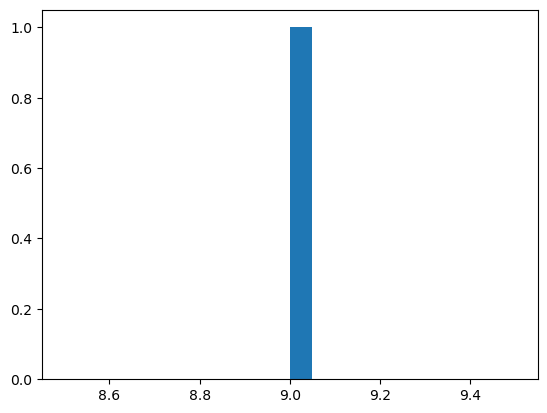

In [33]:
plt.hist(collision_props['resp_lat_ms'], bins=20)
plt.show()

### Plot some things

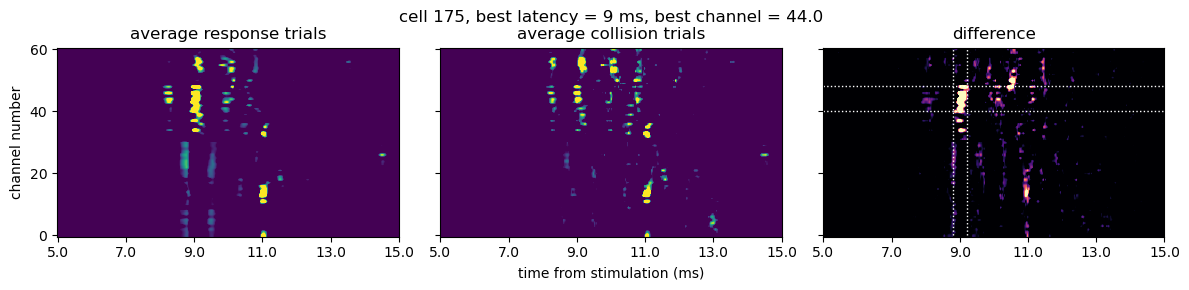

In [34]:
''' difference in pre- vs. post-collision hash for all significant cells '''
# plotting params
start_t = 5e-3
end_t = 15e-3
v_min = 10
v_max = 25
v_thresh = 20
diff_min = 5
diff_max = 20

# data params
sig_cell_idx = collision_props['sig_cell_idx']
sig_cell_ids = collision_props['sig_cell_IDs']

# set the time window to look at
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)
n_bins = end_idx - start_idx

for j, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    # get the relevant hash
    pol_id = collision_props['polarity_idx'][j]
    stim_hash = all_stim_hash[pol_id]
    stim_events = stim_hash[:, :, start_idx:end_idx]
    
    # get the collision trials
    sorted_trial_idx = collision_props["sorted_trial_idx"][j]
    best_col_idx = collision_props["best_col_idx"][j] + 1
    
    # take the median collision vs. non-collision
    sorted_hash = stim_events[sorted_trial_idx]
    collision_hash = np.median(sorted_hash[:best_col_idx], axis=0)
    response_hash = np.median(sorted_hash[best_col_idx:], axis=0)
    hash_diff = response_hash - collision_hash
    
    # plot the hashes and difference
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    ax[0].imshow(-response_hash, clim=[v_min, v_max],
                     aspect='auto', cmap='viridis')
    ax[0].set_title(f'average response trials')
    ax[1].imshow(-collision_hash, clim=[v_min, v_max],
                 aspect='auto', cmap='viridis')
    ax[2].imshow(-hash_diff, clim=[diff_min, diff_max],
                 aspect='auto', cmap='magma')
    ax[2].set_title(f'difference')
    
    # plot the rough stim response time
    lat_ms = collision_props['resp_lat_ms'][j]
    lat_samp = (lat_ms/1000 - start_t)*sampling_rate
    ax[2].vlines(lat_samp-6, 0, n_channels-1, 
              colors='w', 
              linestyles='dotted', lw=1)
    ax[2].vlines(lat_samp+6, 0, n_channels-1, 
              colors='w', 
              linestyles='dotted', lw=1)
    
    # plot the rough channel
    best_ch = wf_ch_idx[c_idx] + collision_props['adj_ch_idx'][j]
    ch_buffer = 4
    ax[2].hlines(best_ch-ch_buffer, 0, n_bins-1, 
              colors='w', 
              linestyles='dotted', lw=1)
    ax[2].hlines(best_ch+ch_buffer, 0, n_bins-1, 
              colors='w', 
              linestyles='dotted', lw=1)
    
    # save the pixel index of the antidromic response
    ch_start = int(best_ch-ch_buffer)
    ch_end = int(best_ch+ch_buffer)
    samp_start = int(lat_samp-6)
    samp_end = int(lat_samp+6)
    cropped_hash = hash_diff[ch_start:ch_end, samp_start:samp_end]

    # ticks and labels
    ax[1].set_title(f'cell {cell}, best latency = {lat_ms} ms, best channel = {best_ch}\naverage collision trials')
    ax[0].set_ylabel('channel number')
    ax[1].tick_params(labelleft=False)
    ax[2].tick_params(labelleft=False)
    ax[1].set_xlabel('time from stimulation (ms)')
    for i in range(3):
        ax[i].set_ylim(ax[i].get_ylim()[::-1])
        ax[i].set_xticks(np.arange(0, n_bins+1, 0.002*sampling_rate))
        ax[i].set_xticklabels(np.arange(start_t*1000, end_t*1000+1, 2))
    plt.tight_layout()
    plt.show()
    
    fig.savefig(f'{save_folder}/{session_id}_{cell}_{stim_pol}.png', 
                      dpi=600, bbox_inches='tight')

In [37]:
''' longer time window (include stim time) '''
''' get box params for all cells '''
# figure params
start_t=-2e-3
end_t=14e-3
v_min=1
v_max=30
lat_buffer = 8

# data params
sig_cell_idx = collision_props['sig_cell_idx']
sig_cell_ids = collision_props['sig_cell_IDs']

# large or small channel range
ch_buffers = np.full(n_sig_cells, 5)
# ch_buffers[0] = np.asarray([3]) # 251003
# ch_buffers[[0, 2]] = np.asarray([3, 3]) # 250929
# ch_buffers[-1] = np.asarray([2]) # 250326

# adjust center channel
# collision_props['adj_ch_idx'][[0, 2]] = np.asarray([1, 1])

# doubling index
idx = np.arange(n_sig_cells)
dbl_idx = np.sort(np.append(idx, idx))
dbl_sig_idx = np.sort(np.append(sig_cell_idx, sig_cell_idx))

# latency ranges
lat_ms = collision_props['resp_lat_ms'].copy()
lat_samp = (lat_ms/1000 - start_t)*sampling_rate
lat_starts = lat_samp[dbl_idx] - lat_buffer
lat_ends = lat_samp[dbl_idx] + lat_buffer
lat_bounds = lat_starts.copy()
lat_bounds[1::2] = lat_ends[1::2]

# channel ranges
best_ch = wf_ch_idx[sig_cell_idx] + collision_props['adj_ch_idx']
ch_starts = best_ch[dbl_idx] - ch_buffers[dbl_idx]
ch_ends = best_ch[dbl_idx] + ch_buffers[dbl_idx]
ch_bounds = ch_starts.copy()
ch_bounds[1::2] = ch_ends[1::2]

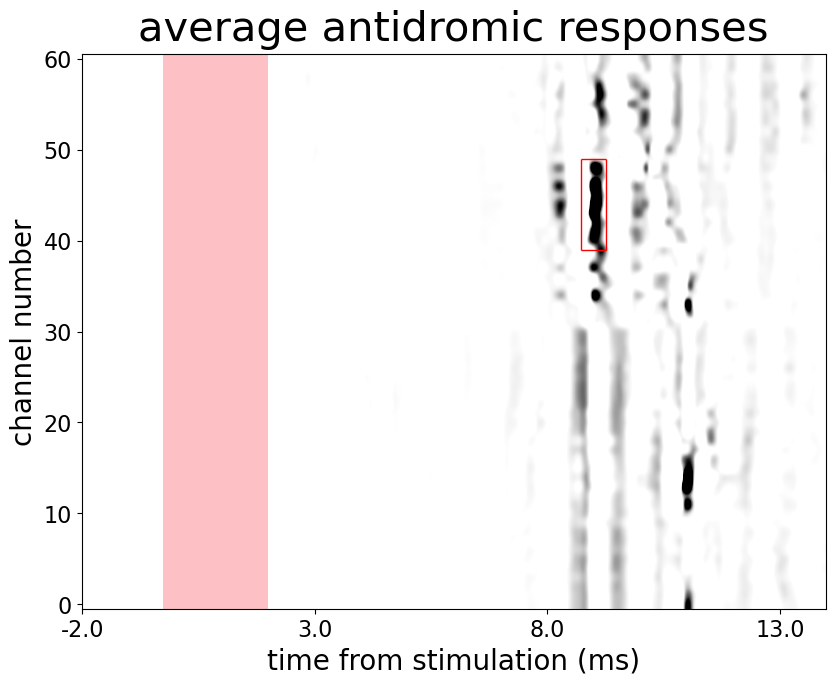

In [39]:
''' plot average hash (350uA) with all cells highlighted '''
box_lw = 1

# avg across stim events
avg_stim = np.median(all_stim_hash[0], axis=0)

# set the time window to look at
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)

# grab that window
stim_events = avg_stim[:, start_idx:end_idx]
n_bins = stim_events.shape[1]

# plot the average hash
f, ax = plt.subplots(1, 1, figsize=(9.6, 7.2))
ax.imshow(-stim_events, clim=[v_min, v_max],
          aspect='auto', cmap='Greys',
          interpolation='gaussian')

# highlight example cell responses
for j, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    j += 1
    i = dbl_sig_idx==c_idx
    ax.vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                 colors='r', linestyles='solid', lw=box_lw)
    ax.hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                 colors='r', linestyles='solid', lw=box_lw)
ylim = ax.get_ylim()
        
# mask stim
ax.fill_betweenx(np.arange(-1, 62),
                 -start_t*sampling_rate-8, 
                 -start_t*sampling_rate+60, 
                 facecolor='xkcd:pale rose', lw=0)

# axes and labels
ax.set_ylim(ylim[::-1])
ax.set_xticks(np.arange(0, n_bins+1, 0.005*sampling_rate))
ax.set_xticklabels(np.arange(start_t*1000, end_t*1000+2, 5))
ax.tick_params(which='major', labelsize=16)
ax.set_xlabel('time from stimulation (ms)', fontsize=20)
ax.set_ylabel('channel number', fontsize=20)
ax.set_title('average antidromic responses', 
             fontsize=30, pad=10)

plt.show()
f.savefig(f'{save_folder}/{session_id}_median_hash_all_cells.png', 
                      dpi=600, bbox_inches='tight')

### Make some nice plots for the example cells

In [40]:
# example_cells = np.asarray([218, 312])
example_cells = all_sig_cells
n_example_cells = example_cells.shape[0]

In [41]:
ex_cell_idx = []
for c_idx, cell in zip(sig_cell_idx, sig_cell_ids):
    if cell in example_cells:
        ex_cell_idx.append(c_idx)
ex_cell_idx = np.asarray(ex_cell_idx).astype(int)
print(f'example cells {good_clusters[ex_cell_idx]}')

example cells [175]


In [42]:
''' get evenly spaced collision and response trial indices for each example cell '''
# plotting params
n_col_trials = 4
n_resp_trials = 4
n_total_trials = n_col_trials + n_resp_trials

# set the time window to look at - traces
start_t = -20e-3 # in seconds
end_t = 20e-3 # in seconds
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)
start_ms = start_t*1000

ex_trial_idx_all = np.full((n_sig_cells, n_total_trials), np.NaN)
ex_latencies_all = np.full((n_sig_cells, n_total_trials), np.NaN)
ex_LR_idx = np.full((n_sig_cells, n_total_trials), np.NaN)
for sig_idx, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    if cell in example_cells:
        # data params
        LR_cell = collision_props['LR_stat'][sig_idx]
        col_idx = collision_props["best_col_idx"][sig_idx]
        pre_stim_lat = collision_props['pre_stim_lat'][sig_idx]

        # all trial indices, clipped at pre-stim start time
        all_trial_idx = collision_props['sorted_trial_idx'][sig_idx]
        trial_latencies = pre_stim_lat[all_trial_idx]
        trial_idx = all_trial_idx[trial_latencies < -sampling_rate*start_t]
        if trial_idx[col_idx+1:].shape[0] < n_resp_trials:
            print(f"cell {cell} not enough long latency trials")
            n_example_cells = n_example_cells - 1
            continue
        elif trial_idx[:col_idx].shape[0] < n_col_trials:
            print(f"cell {cell} not enough collision trials")
            n_example_cells = n_example_cells - 1
            continue

        # collision trial index, sorted by latency
        col_latencies = pre_stim_lat[trial_idx[:col_idx+1]]
        if cell == 255:
            spaced_lat, step = np.linspace(col_latencies[5], col_latencies[-1],
                                           n_col_trials, retstep=True)
        else:
            spaced_lat, step = np.linspace(col_latencies[1], col_latencies[-1],
                                           n_col_trials, retstep=True)
        col_lat_idx = np.full(n_col_trials, np.NaN)
        for i, l in enumerate(spaced_lat):
            col_lat_idx[i] = np.argmin(np.abs(col_latencies-l))
            if col_lat_idx[i] == col_lat_idx[i-1]:
                col_lat_idx[i] = col_lat_idx[i] + 1
        col_trial_idx = trial_idx[col_lat_idx.astype(int)]
        subsamp_latencies = np.round(pre_stim_lat[col_trial_idx]/sampling_rate*1000, 2)

        # response trial index, sorted by latency
        n_total_resp = trial_idx[col_idx+1:].shape[0]
        resp_latencies = pre_stim_lat[trial_idx[col_idx+1:]]
        step_idx = np.argmin(np.abs(resp_latencies-(col_latencies[-1]+step)))
        if np.round(col_idx / n_total_resp) > 0:
            spacer = step_idx // np.round(col_idx / n_total_resp)
        else:
            spacer = step_idx
        min_r_idx = np.max((col_idx+int(spacer), col_idx+1))
        resp_latencies = pre_stim_lat[trial_idx[min_r_idx:]]
        spaced_lat = np.linspace(resp_latencies[0], resp_latencies[-1], n_resp_trials)
        resp_lat_idx = np.full(n_resp_trials, np.NaN)
        for i, l in enumerate(spaced_lat):
            resp_lat_idx[i] = np.argmin(np.abs(resp_latencies-l)) + min_r_idx
            if resp_lat_idx[i] == resp_lat_idx[i-1]:
                resp_lat_idx[i] = resp_lat_idx[i] + 1
        resp_trial_idx = trial_idx[resp_lat_idx.astype(int)]
        subsamp_latencies = np.append(subsamp_latencies,
                                      np.round(pre_stim_lat[resp_trial_idx]/sampling_rate*1000, 2))
        ex_trial_idx = np.append(col_trial_idx, resp_trial_idx)
        assert all(np.sort(ex_trial_idx) == np.intersect1d(all_trial_idx, ex_trial_idx))

        # get the trial index for the likelihood ratio
        LR_trial_idx = np.full(n_total_trials, np.NaN)
        j = 0
        for k, tr in enumerate(all_trial_idx):
            if tr in ex_trial_idx:
                LR_trial_idx[j] = k
                j += 1
        LR_trial_idx = LR_trial_idx.astype(int)
        ex_LR_idx[sig_idx] = LR_trial_idx

        # flip trial order so longer latencies come first
        ex_latencies_all[sig_idx] = subsamp_latencies[::-1]
        ex_trial_idx_all[sig_idx] = ex_trial_idx[::-1]

In [44]:
''' get box params for all cells '''
start_t_hash = 4e-3 # in seconds
end_t_hash = 14e-3 # in seconds
start_t_adj_hash = start_t_hash + t_pre
end_t_adj_hash = end_t_hash + t_pre
start_idx_hash = np.round(start_t_adj_hash*sampling_rate).astype(int)
end_idx_hash = np.round(end_t_adj_hash*sampling_rate).astype(int)
n_bins_hash = end_idx_hash - start_idx_hash

# figure params
lat_buffer = 8

# data params
sig_cell_idx = collision_props['sig_cell_idx']
sig_cell_ids = collision_props['sig_cell_IDs']

# large or small channel range
ch_buffers = np.full(n_sig_cells, 5)
# ch_buffers[[0, 2]] = np.asarray([3, 3])
# ch_buffers[1] = 3

# doubling index
idx = np.arange(n_sig_cells)
dbl_idx = np.sort(np.append(idx, idx))
dbl_sig_idx = np.sort(np.append(sig_cell_idx, sig_cell_idx))

# latency ranges
lat_ms = collision_props['resp_lat_ms'].copy()
lat_samp = (lat_ms/1000 - start_t_hash)*sampling_rate
lat_starts = lat_samp[dbl_idx] - lat_buffer
lat_ends = lat_samp[dbl_idx] + lat_buffer
lat_bounds = lat_starts.copy()
lat_bounds[1::2] = lat_ends[1::2]

# channel ranges
best_ch = wf_ch_idx[sig_cell_idx] + collision_props['adj_ch_idx'] #- 1
ch_starts = best_ch[dbl_idx] - ch_buffers[dbl_idx]
ch_ends = best_ch[dbl_idx] + ch_buffers[dbl_idx]
ch_bounds = ch_starts.copy()
ch_bounds[1::2] = ch_ends[1::2]

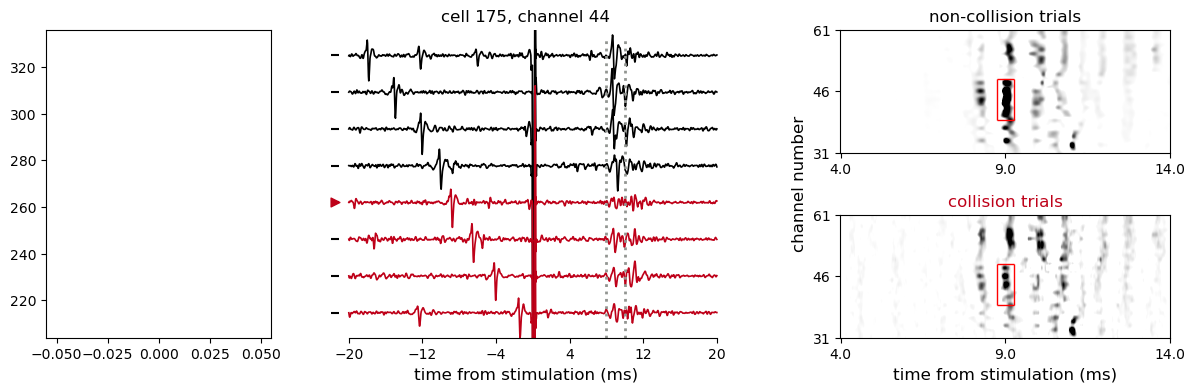

In [45]:
''' plot change point statistic and traces side-by-side '''
# plotting params
y_scales = np.full(n_example_cells, 200)
# y_scales[[1, 2]] = np.asarray([500, 900])
x_range = np.arange(n_total_trials)
aligned_time = np.linspace(start_t*1000, end_t*1000, end_idx - start_idx)

change_pt_lw = 2.5
trace_lw = 1.2
scatter_size = 40
box_lw = 1
lat_lw = 2

for sig_idx, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    if cell in example_cells:
        # data params
        pre_stim_lat = collision_props['pre_stim_lat'][sig_idx]
        col_idx = collision_props["best_col_idx"][sig_idx].astype(int)
        LR_cell = collision_props['LR_stat'][sig_idx]
        LR_trial_idx = ex_LR_idx[sig_idx].astype(int)
        ex_trial_idx = ex_trial_idx_all[sig_idx].astype(int)
        subsamp_latencies = ex_latencies_all[sig_idx]        
        pol_id = int(collision_props['polarity_idx'][sig_idx])

        # fig params
        gs_kw = dict(width_ratios=[15, 28, 1, 22], hspace=0.5, wspace=0.18)
        f, ax = plt.subplot_mosaic([[0, 1, 3, 20], [0, 1, 3, 21]],
                                   figsize=(14.5, 4), gridspec_kw=gs_kw)
        y_scale = y_scales[example_cells==cell]
        ax[3].spines['top'].set_visible(False)
        ax[3].spines['left'].set_visible(False)
        ax[3].spines['bottom'].set_visible(False)
        ax[3].spines['right'].set_visible(False)
        ax[3].set_xticks([])
        ax[3].set_yticks([])

#         # PLOT ALL LR VS. SHUFFLE
#         all_trial_idx = collision_props['sorted_trial_idx'][sig_idx]
#         trial_latencies = pre_stim_lat[all_trial_idx]
#         n_dist = LR_cell.shape[0]
#         LR_latencies = trial_latencies[:-1][trial_latencies[:-1] < -sampling_rate*start_t]
#         ex_LR = LR_cell[trial_latencies[:-1] < -sampling_rate*start_t]

#         # get the shuffle and significant peaks
#         shuff_LR = all_shuffs[pol_id]
#         cell_shuff = shuff_LR[c_idx, :n_dist][trial_latencies[:-1] < -sampling_rate*start_t]
#         shuff_99 = np.percentile(cell_shuff, 99, axis=1)
#         LR_peaks_idx, _ = find_peaks(ex_LR)
#         n_peaks = LR_peaks_idx.shape[0]
#         sig_peaks = ex_LR[LR_peaks_idx] > shuff_99[LR_peaks_idx]

#         # normalize s.t. 0 is mean of shuffle and 1 is max LR
#         min_norm = np.mean(cell_shuff)
#         max_norm = np.max(ex_LR - min_norm)
#         norm_LR = (ex_LR - min_norm) / max_norm
#         norm_shuff = (shuff_99 - min_norm) / max_norm

#         # plot the data and shuffle
#         ax[0].plot(norm_LR, LR_latencies, 'k', lw=change_pt_lw)
#         ax[0].plot(norm_shuff, LR_latencies, 'xkcd:grey', 
#                    lw=change_pt_lw, ls='dashed')

#         # mark the exmaple trials
#         ex_lat_LR = np.intersect1d(LR_latencies, np.round(subsamp_latencies/1000*sampling_rate))
#         yvals_LR = np.full(ex_lat_LR.shape[0], 1.1)
#         ax[0].scatter(yvals_LR, ex_lat_LR, c='k', s=scatter_size, marker='_')
#         ax[0].scatter(1.1, trial_latencies[col_idx], c='xkcd:scarlet', s=scatter_size, marker='>')
#         ex_lat_traces = np.linspace(LR_latencies[0], LR_latencies[-1], n_total_trials)

#         # ticks and labels
#         ax[0].set_title(f'cell {cell}', fontsize=axis_label)
#         ax[0].set_yticks([])
#         ax[0].yaxis.tick_right()
#         ax[0].set_ylim(LR_latencies[0]-50, LR_latencies[-1]+35)
#         ax[0].spines['right'].set_bounds(LR_latencies[0], LR_latencies[-1])
#         ax[0].tick_params(labelright=False, which='major', labelsize=tick_label)

#         ax[0].set_xticks([0, 0.5, 1])
#         ax[0].set_xlim(1.15, -0.2)
#         ax[0].spines['bottom'].set_bounds(1, 0)
#         ax[0].set_xlabel('change-point stat.', fontsize=axis_label)

#         ax[0].spines['top'].set_visible(False)
#         ax[0].spines['left'].set_visible(False)
#         ax[0].spines['right'].set_visible(False)

        # PLOT THE TRACES FROM EXAMPLE TRIALS
        # channel index
        best_ch = wf_ch_idx[c_idx]

        # grab the relevant ephys data
        med_sub_data = all_filt_data[pol_id]
        stim_events = med_sub_data[best_ch, start_idx:end_idx, ex_trial_idx]
        n_stim_events, n_bins = stim_events.shape

        # plot each trace shifted vertically from the others
        yvals_traces = np.full(stim_events.shape[0], 0)
        for i, s_event in enumerate(stim_events):
            yvals_traces[i] = -i*y_scale
            if i >= n_resp_trials:
                ax[1].plot(aligned_time, s_event-i*y_scale, 'xkcd:scarlet', lw=trace_lw)
            else:
                ax[1].plot(aligned_time, s_event-i*y_scale, 'k', lw=trace_lw)    
        xvals_traces = np.full(stim_events.shape[0], start_ms-1.5)        
        ax[1].scatter(xvals_traces, yvals_traces, c='k', s=scatter_size, marker='_')
        ax[1].scatter(start_ms-1.5, yvals_traces[n_col_trials], c='xkcd:scarlet', s=scatter_size, marker='>')

        # axis params
        ax[1].set_title(f'cell {cell}, channel {best_ch}', fontsize=axis_label)
        ax[1].spines['bottom'].set_bounds(aligned_time[0], aligned_time[-1])
        ax[1].set_xticks(np.arange(aligned_time[0], aligned_time[-1]+1, 8))
        ax[1].set_xlabel('time from stimulation (ms)', fontsize=axis_label)
        ax[1].set_ylim([(-n_stim_events)*(y_scale*0.96), y_scale*0.7])
        ax[1].tick_params(which='major', labelsize=tick_label)

        # plot the stim response time
        ylims = ax[1].get_ylim()
        lat_ms = collision_props['resp_lat_ms'][sig_idx]
        ax[1].vlines(lat_ms-1, ylims[0], 
                     ylims[1]-(y_scale*0.2), 
                  colors='xkcd:grey', 
                  linestyles='dotted', lw=lat_lw)
        ax[1].vlines(lat_ms+1, ylims[0], 
                     ylims[1]-(y_scale*0.2), 
                  colors='xkcd:grey', 
                  linestyles='dotted', lw=lat_lw)
        
        # plot the change point window
        xlims = ax[0].get_xlim()
        lat_samp = lat_ms/1000*sampling_rate
        buff_samp = 2e-3*sampling_rate
        ax[0].hlines(lat_samp-buff_samp, xlims[0], 0, 
                  colors='xkcd:grey', 
                  linestyles='dotted', lw=lat_lw)
        ax[0].hlines(lat_samp+buff_samp, xlims[0], 0, 
                  colors='xkcd:grey', 
                  linestyles='dotted', lw=lat_lw)

        # hide other axes  
        ax[1].spines['right'].set_visible(False)
        ax[1].spines['top'].set_visible(False)
        ax[1].spines['left'].set_visible(False)
        ax[1].set_yticks([])
        
        # PLOT THE COLLISION AND RESPONSE HEAT MAPS
        # get the median hash for collision and response trials
        sorted_trial_idx = collision_props["sorted_trial_idx"][sig_idx]
        stim_hash = all_stim_hash[pol_id]
        sorted_hash = stim_hash[sorted_trial_idx, :, start_idx_hash:end_idx_hash]
        collision_hash = np.median(sorted_hash[:col_idx+1], axis=0)
        response_hash = np.median(sorted_hash[col_idx+1:], axis=0)
        
        # plot the median collision and response hash
        ax[20].imshow(-response_hash, clim=[v_min, v_max],
                     aspect='auto', cmap='Greys', interpolation="gaussian")
        ax[21].imshow(-collision_hash, clim=[v_min, v_max],
                         aspect='auto', cmap='Greys', interpolation="gaussian")
        
        # plot the bounding box for this cell
        i = dbl_sig_idx==c_idx
        ax[20].vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='red', linestyles='solid', lw=box_lw)
        ax[20].hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='red', linestyles='solid', lw=box_lw)
        ax[21].vlines(lat_bounds[i], ch_starts[i], ch_ends[i], 
                     colors='red', linestyles='solid', lw=box_lw)
        ax[21].hlines(ch_bounds[i], lat_starts[i], lat_ends[i], 
                     colors='red', linestyles='solid', lw=box_lw)
        
        # axes and labels
        if best_ch in A_shank:
            ymin = A_shank[0]
            ymax = A_shank[-1]
        else:
            ymin = B_shank[0]
            ymax = B_shank[-1]
        ax[20].set_title('non-collision trials', fontsize=axis_label)
        ax[21].set_title('collision trials', color='xkcd:scarlet', fontsize=axis_label)
        for j in np.arange(20, 22):
            ax[j].set_ylim([ymin, ymax])
            ax[j].set_xticks(np.arange(0, n_bins_hash+1, 0.005*sampling_rate))
            ax[j].set_xticklabels(np.arange(start_t_hash*1000, end_t_hash*1000+2, 5))
            ax[j].set_yticks(np.arange(ymin, ymax+2, 15))
            ax[j].tick_params(which='major', labelsize=tick_label)
        ax[21].set_ylabel('channel number', y=1.25, fontsize=axis_label)
        ax[21].set_xlabel('time from stimulation (ms)', fontsize=axis_label)

        plt.show()

        f.savefig(f'{save_folder}{session_id}_traces_LR_heatmaps_{cell}.png', 
                  dpi=600, bbox_inches='tight')

### Plots comparing antidromic responders to the full pop
- waveform properties plot
    - z-score??
- average waveforms all cells
- firing rate over time in session

In [46]:
from sklearn.cluster import KMeans
import matplotlib.ticker as mticker

In [47]:
# get the waveform properties
fr = waveform_struct['meanRate']
width = np.zeros(n_cells)
assym = np.zeros(n_cells)
for wf_idx in range(n_cells):
    best_ch = wf_ch_idx[wf_idx]
    width[wf_idx] = waveform_analysis.calc_spike_width(mean_waveforms[wf_idx, best_ch])
    assym[wf_idx] = waveform_analysis.calc_amp_assym(mean_waveforms[wf_idx, best_ch])    

In [48]:
# get the log firing rate
log_fr = np.log10(fr)

# consolidate the params for clustering
wf_params = np.column_stack([assym, width])
wf_params = np.column_stack([wf_params, log_fr])

# zscore for kmeans
zscore_params = stats.zscore(wf_params, axis=0)

# kmeans cluster
kmeans = KMeans(n_clusters=2, n_init=100, random_state=1234)
kmeans.fit(zscore_params)
H = kmeans.cluster_centers_
W_raw = kmeans.labels_

C:\Users\ilow1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [49]:
# for log scaling the FR axis
def log_tick_formatter(val, pos=None):
    return f"$10^{{{val:g}}}$"

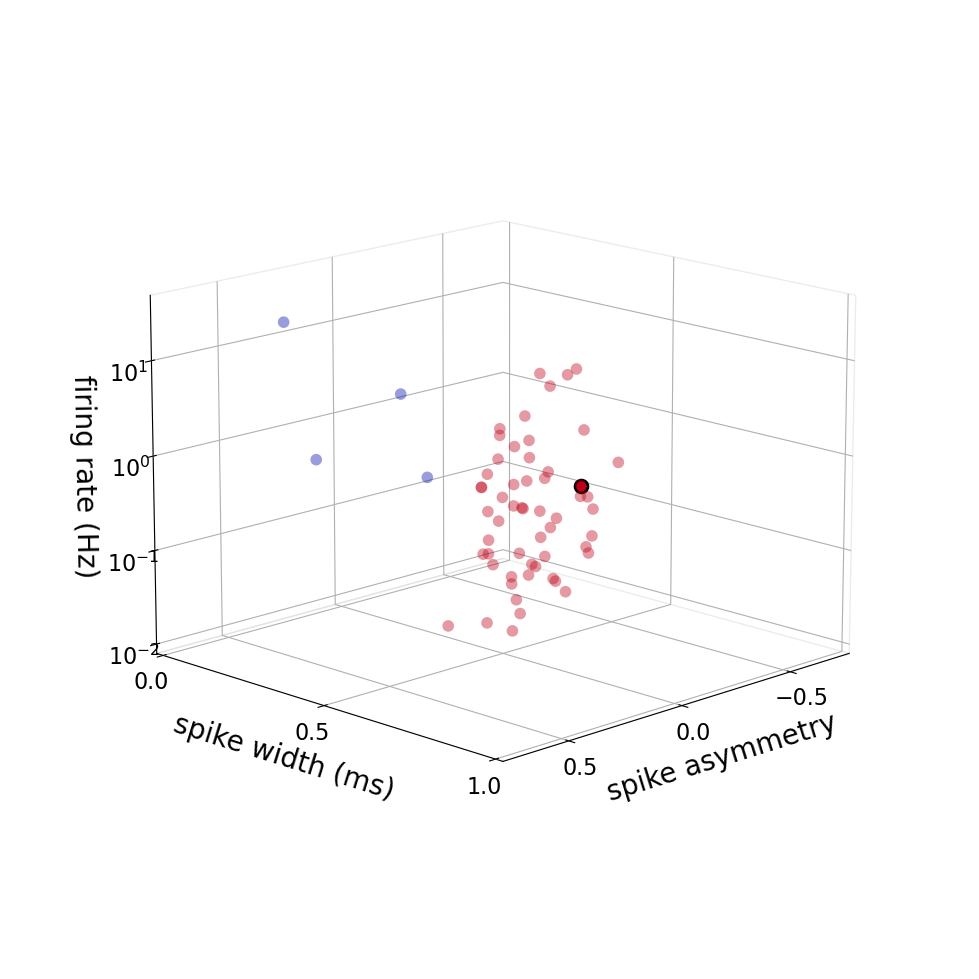

In [50]:
''' plot the waveform properties '''
fig = plt.figure(figsize=(16, 8))
ax = plt.axes([0, 0, .6, 1.2], projection='3d')
axis_label = 20
tick_label = 16

scatter_size = 70
scatter_size_sig = 85
scatter_lw = 2

clu1_idx = W_raw.astype(bool)
clu2_idx = np.abs(W_raw - 1).astype(bool)

# all excitatory cells
ax.scatter(assym[clu1_idx],
           width[clu1_idx],
           log_fr[clu1_idx],
           c='xkcd:scarlet',
           alpha=0.4, lw=0, 
           s=scatter_size, zorder=0)

# all inhibitory cells
ax.scatter(assym[clu2_idx],
           width[clu2_idx],
           log_fr[clu2_idx],
           c='xkcd:cobalt blue', 
           alpha=0.4, lw=0, 
           s=scatter_size, zorder=0)

# significant projection units
ax.scatter(assym[sig_cell_idx],
           width[sig_cell_idx],
           log_fr[sig_cell_idx],
           c='xkcd:scarlet', edgecolors='k', 
           alpha=1, lw=scatter_lw, 
           s=scatter_size_sig, zorder=1)

# labels
ax.set_xlabel('spike asymmetry', fontsize=axis_label, labelpad=18)
ax.set_ylabel('spike width (ms)', fontsize=axis_label, labelpad=18)
ax.set_zlabel('firing rate (Hz)', fontsize=axis_label, labelpad=15)
ax.tick_params(which='major', labelsize=tick_label)

# log scale the z-axis
ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# limits
ax.set_xlim([-0.75, 0.75])
ax.set_xticks([-0.5, 0, 0.5])
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

# background color
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('xkcd:grey')
ax.yaxis.pane.set_edgecolor('xkcd:grey')
ax.zaxis.pane.set_edgecolor('xkcd:grey')
ax.xaxis.pane.set_color('xkcd:light grey')
ax.yaxis.pane.set_color('xkcd:light grey')
ax.zaxis.pane.set_color('xkcd:light grey')

ax.view_init(azim=45, elev=15)
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.show()

fig.savefig(f'{save_folder}{session_id}_waveform_props.png', 
                  dpi=600, bbox_inches='tight')

In [51]:
''' plot example waveforms - compare antidromic responses to average wf '''
# set the time window to look at
max_lat_t = 20e-3
start_t = 2e-3 # in seconds
end_t = 16e-3 # in seconds
start_t_adj = start_t + t_pre
end_t_adj = end_t + t_pre
start_idx = np.round(start_t_adj*sampling_rate).astype(int)
end_idx = np.round(end_t_adj*sampling_rate).astype(int)
samp_buffer_t = 3e-3
samp_buffer = samp_buffer_t*sampling_rate

# get the aligned traces from response trials
antidromic_waveforms = []
antidromic_wf_avg = []
for sig_idx, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    # polarity/amplitude
    pol_id = int(collision_props['polarity_idx'][sig_idx])
    
    # best channel
    best_ch = wf_ch_idx[c_idx]
    
    # sorted latencies
    pre_stim_lat = collision_props['pre_stim_lat'][sig_idx]
    col_idx = collision_props["best_col_idx"][sig_idx].astype(int) + 1    
    lat_sort_idx = np.argsort(pre_stim_lat)
    sorted_latencies = pre_stim_lat[lat_sort_idx]

    # get the trial indices
    all_stim_idx = np.arange(sorted_latencies.shape[0])
    all_stim_idx = all_stim_idx[np.isfinite(sorted_latencies)]
    resp_trial_idx = all_stim_idx[col_idx:]

    # grab the relevant ephys data
    med_sub_data = all_filt_data[pol_id]
    responses_jit = med_sub_data[best_ch, start_idx:end_idx, resp_trial_idx]
    n_response_trials, n_samp = responses_jit.shape
    avg_responses_jit = np.mean(responses_jit, axis=0)
    half_n_bins = int(n_samp//2 - samp_buffer)
    
    # align the peaks
    jit_peak_idx = np.argmax(-avg_responses_jit)
    samp_idx = np.arange(jit_peak_idx-samp_buffer, jit_peak_idx+samp_buffer).astype(int)
    responses_align = np.zeros((n_response_trials, half_n_bins*2))
    for i in range(n_response_trials):
        peak_idx = np.argmax(-responses_jit[i, samp_idx])
        peak_idx_adj = peak_idx + jit_peak_idx-samp_buffer
        start_samp_idx = int(peak_idx_adj - half_n_bins)
        end_samp_idx = int(peak_idx_adj + half_n_bins)
        if start_samp_idx < 0:
            start_samp_idx = 0
            end_samp_idx = half_n_bins*2
        elif end_samp_idx > n_samp:
            start_samp_idx = n_samp - half_n_bins*2
            end_samp_idx = n_samp     
        responses_align[i] = responses_jit[i, start_samp_idx:end_samp_idx]
    avg_responses_align = np.mean(responses_align, axis=0)    
    
    # normalize to the waveform peak
    peak_amp_hash = np.max(-avg_responses_align)
    
    # save for each cell
    antidromic_waveforms.append(responses_align/peak_amp_hash)
    antidromic_wf_avg.append(avg_responses_align/peak_amp_hash)
antidromic_wf_avg = np.asarray(antidromic_wf_avg)

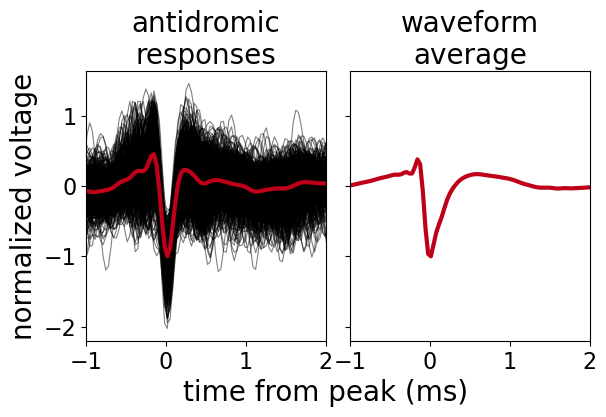

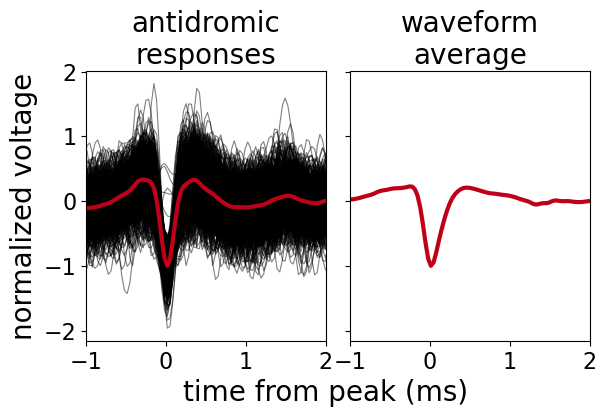

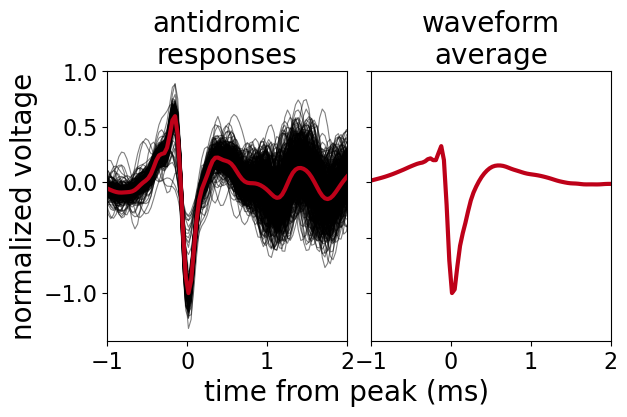

In [68]:
''' TODO: grab some example spontaneous waveforms from getSessionWaveforms '''
# get the aligned time in ms
aligned_time = np.linspace(-half_n_bins/sampling_rate*1000, half_n_bins/sampling_rate*1000, half_n_bins*2)
n_wf_samp = mean_waveforms.shape[-1]
# w_ratio = half_n_bins*2/n_wf_samp

title_size = 30
lw_single = 0.8
lw_mean = 3

for sig_idx, (c_idx, cell) in enumerate(zip(sig_cell_idx, sig_cell_ids)):
    # data params
    best_ch = wf_ch_idx[c_idx]
    wf_avg = mean_waveforms[c_idx][best_ch]
    peak_amp_wf = np.max(-wf_avg)
    spont_wf = antidromic_waveforms[sig_idx]
    anti_avg = antidromic_wf_avg[sig_idx]
    anti_responses = antidromic_waveforms[sig_idx]
    
    # aligned waveform time in ms
    wf_peak = np.argmax(-wf_avg)
    post_samp = n_wf_samp - wf_peak
    pre_samp = n_wf_samp - post_samp
    aligned_wf_t = np.linspace(-pre_samp/sampling_rate*1000, post_samp/sampling_rate*1000, n_wf_samp)

#     f, ax = plt.subplots(1, 2, figsize=(6, 3), width_ratios=[w_ratio, 1], sharey=True)
    gs_kw = dict(wspace=0.1)
    f, ax = plt.subplots(1, 2, figsize=(6.5, 3.5), sharey=True, gridspec_kw=gs_kw)
    
    # plot antidromic responses
    ax[0].plot(aligned_time, anti_responses.T,
               'k', lw=lw_single, alpha=0.5)
    ax[0].plot(aligned_time, anti_avg,
               'xkcd:scarlet', lw=lw_mean)
    
    # plot average waveform
    ax[1].plot(aligned_wf_t, wf_avg/peak_amp_wf, 
               'xkcd:scarlet', lw=lw_mean)

    # ticks and labels
    ax[0].set_xlim([-1, 2])
    ax[1].set_xlim([-1, 2])
#     ax[0].set_yticks(np.arange(-1.5, 0.76, 0.75))
    ax[0].set_ylabel('normalized voltage', fontsize=axis_label)
    ax[1].set_xlabel('time from peak (ms)', fontsize=axis_label, x=-0.1)
    ax[0].set_title(f'antidromic\nresponses', fontsize=axis_label, pad=5)
    ax[1].set_title(f'waveform\naverage', fontsize=axis_label, pad=5)
    ax[0].tick_params(which='major', labelsize=tick_label)
    ax[1].tick_params(which='major', labelsize=tick_label)

#     plt.tight_layout()
    plt.show()
    f.savefig(f'{save_folder}/{cell}_antidromic_waveforms.png', 
              dpi=600, bbox_inches='tight')